In [44]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [45]:
df = pd.read_csv('/content/tesla_deliveries_dataset_2015_2025.csv')

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [47]:
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [48]:
print(df.head())
print(df.shape)
print(df.info())

   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640  
2          

In [49]:
print(df.isnull().sum())

# Duplicate rows
print("Duplicates:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64
Duplicates: 0


In [50]:
print(df.describe())

              Year        Month  Estimated_Deliveries  Production_Units  \
count  2640.000000  2640.000000           2640.000000       2640.000000   
mean   2020.000000     6.500000           9922.199621      10655.847348   
std       3.162877     3.452707           3935.950093       4260.600858   
min    2015.000000     1.000000             48.000000         50.000000   
25%    2017.000000     3.750000           7292.000000       7828.250000   
50%    2020.000000     6.500000           9857.000000      10546.500000   
75%    2023.000000     9.250000          12510.250000      13469.000000   
max    2025.000000    12.000000          25704.000000      28939.000000   

       Avg_Price_USD  Battery_Capacity_kWh     Range_km  CO2_Saved_tons  \
count    2640.000000           2640.000000  2640.000000     2640.000000   
mean    84907.340330             87.059470   500.257576      744.076989   
std     20123.258036             20.836265   120.868549      353.221224   
min     50003.700000    

In [51]:
df['Region'].value_counts()

,count
Region,
Europe,660
Asia,660
North America,660
Middle East,660


In [52]:
df['Source_Type'].value_counts()

,count
Source_Type,
Interpolated (Month),884
Official (Quarter),884
Estimated (Region),872


In [53]:
model_sales = df.groupby("Model")["Estimated_Deliveries"].sum()
model_sales.sort_values(ascending=False)


,Estimated_Deliveries
Model,
Model S,5380385
Model 3,5321919
Model Y,5225284
Model X,5157240
Cybertruck,5109779


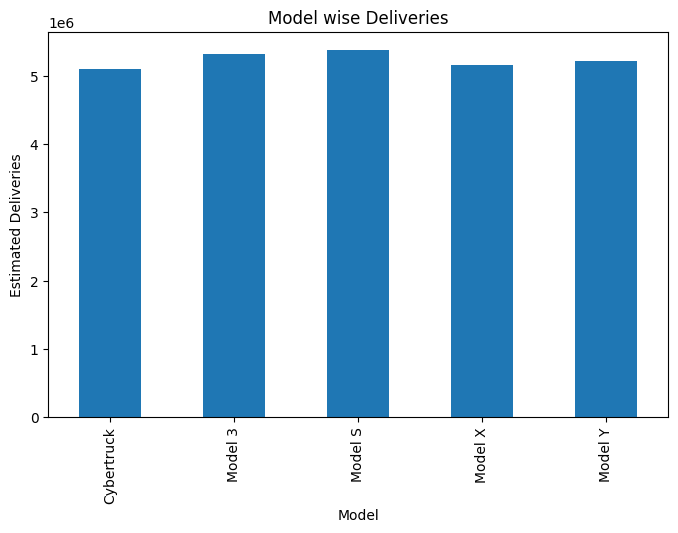

In [54]:
plt.figure(figsize=(8,5))
model_sales.plot(kind='bar')

plt.title("Model wise Deliveries")
plt.xlabel("Model")
plt.ylabel("Estimated Deliveries")

plt.show()


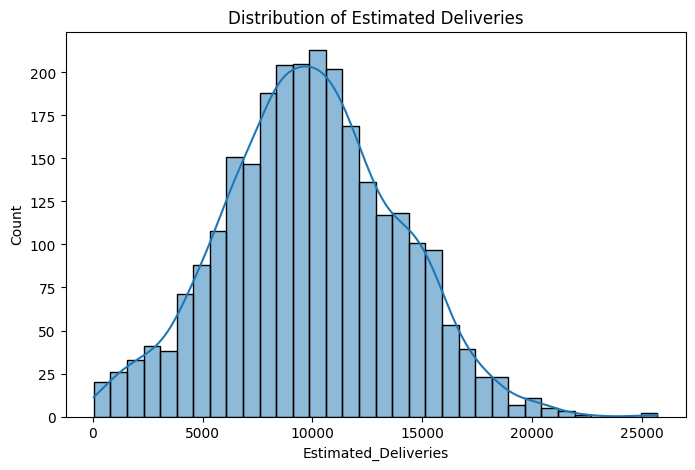

In [55]:
plt.figure(figsize=(8,5))
sns.histplot(df['Estimated_Deliveries'], kde=True)
plt.title("Distribution of Estimated Deliveries")
plt.show()

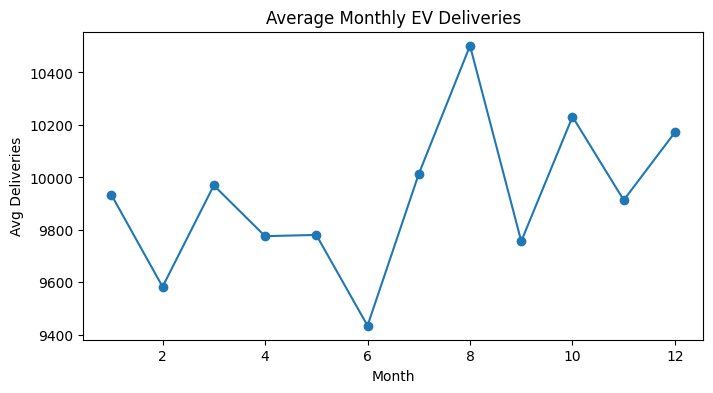

In [56]:
monthly_sales = df.groupby('Month')['Estimated_Deliveries'].mean()

plt.figure(figsize=(8,4))
monthly_sales.plot(kind='line', marker='o')
plt.title("Average Monthly EV Deliveries")
plt.ylabel("Avg Deliveries")
plt.show()

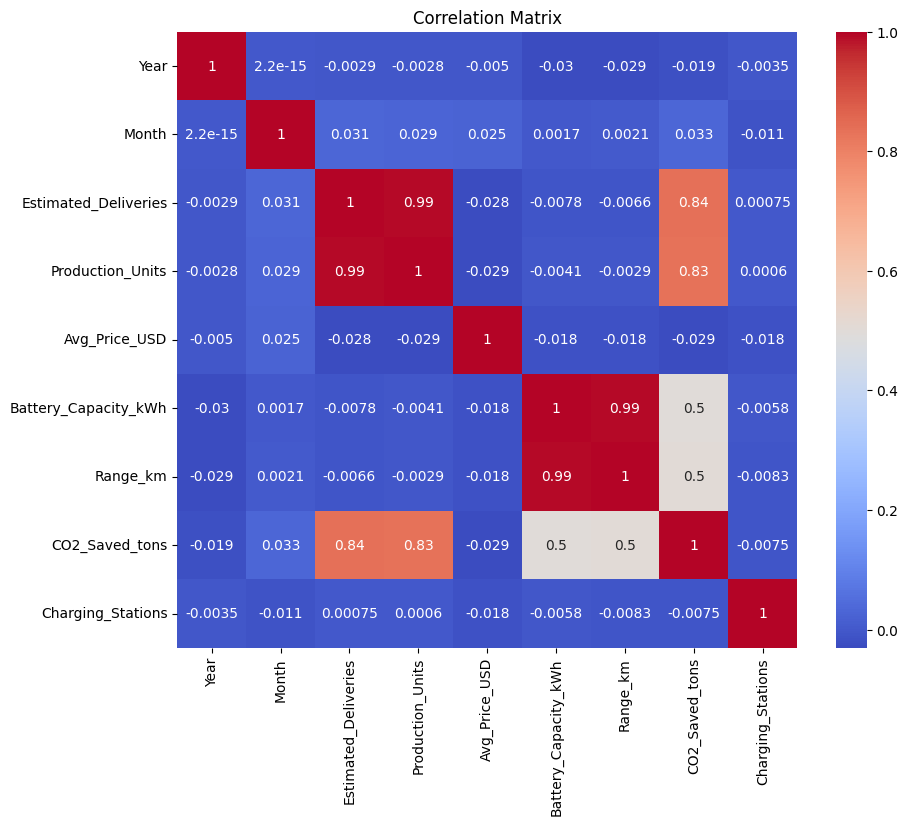

In [57]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()


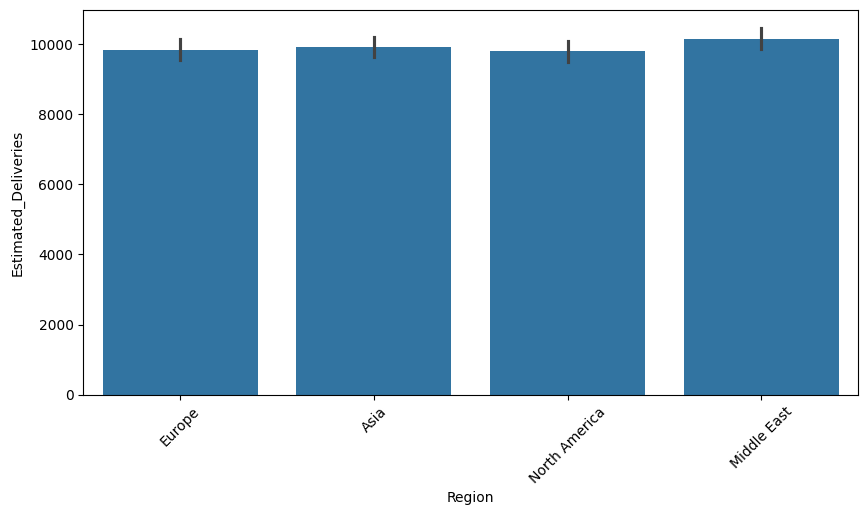

In [58]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Region',
    y='Estimated_Deliveries',
    data=df
)

plt.xticks(rotation=45)
plt.show()

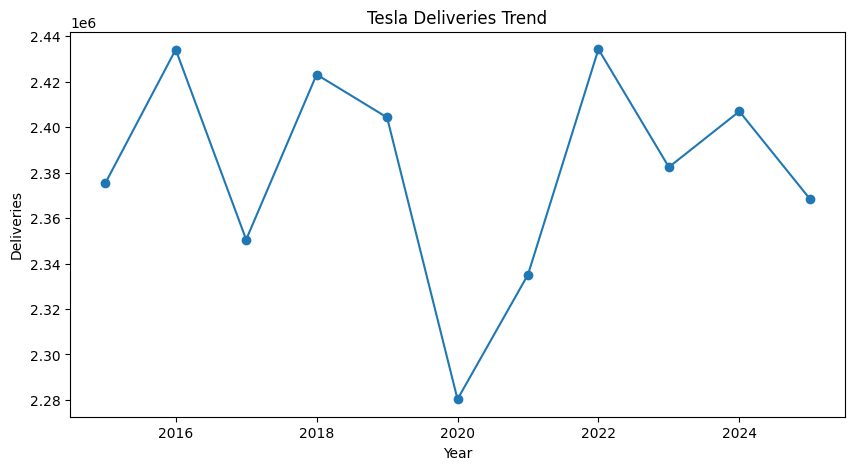

In [59]:
yearly = df.groupby('Year')['Estimated_Deliveries'].sum()

yearly.plot(
    kind='line',
    marker='o',
    figsize=(10,5)
)

plt.title("Tesla Deliveries Trend")
plt.ylabel("Deliveries")
plt.show()

In [60]:
print("Regions:", df['Region'].unique())
print("Models:", df['Model'].unique())
print("Source Types:", df['Source_Type'].unique())

Regions: ['Europe' 'Asia' 'North America' 'Middle East']
Models: ['Model S' 'Model X' 'Model 3' 'Model Y' 'Cybertruck']
Source Types: ['Interpolated (Month)' 'Official (Quarter)' 'Estimated (Region)']


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


,ds,yhat,yhat_lower,yhat_upper
139,2026-08-01,210133.816846,191842.369572,227660.336155
140,2026-09-01,191848.226006,172916.097869,210835.612047
141,2026-10-01,204302.382145,186414.456020,223160.660708
142,2026-11-01,198537.171597,179270.105981,219272.657493
143,2026-12-01,203612.073517,184519.929743,222129.721495


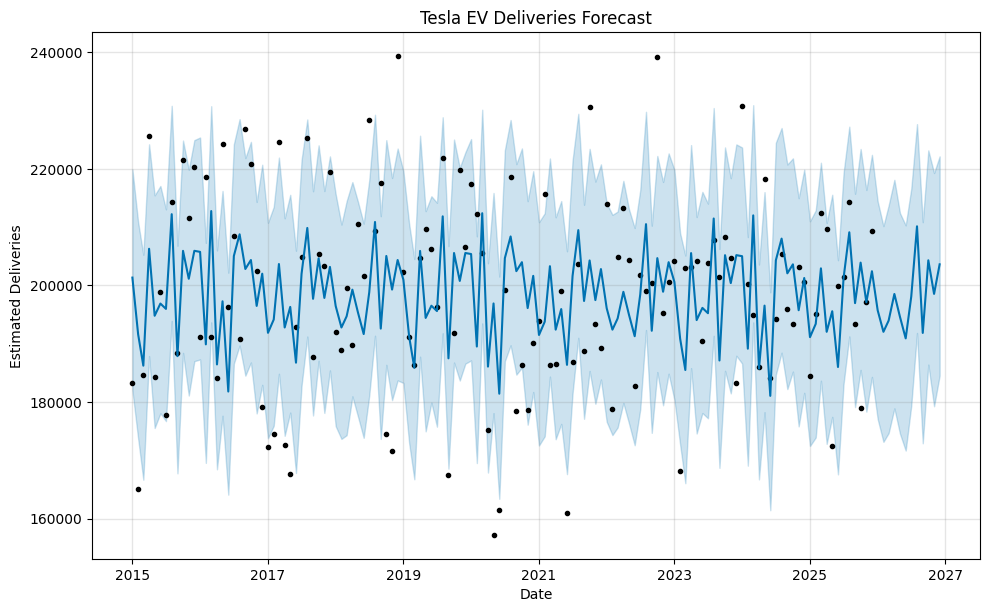

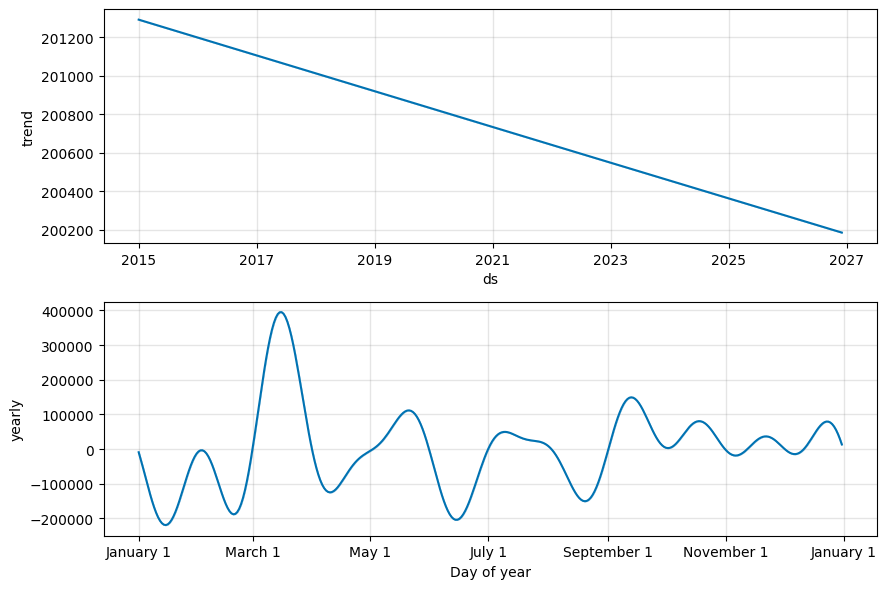

In [61]:
from prophet import Prophet

# Prepare the time series data for Prophet
prophet_df = ts.rename(columns={'Date': 'ds', 'Estimated_Deliveries': 'y'})

# Initialize and fit the Prophet model
m = Prophet()
m.fit(prophet_df)

# Create a future dataframe for forecasting
# Forecast for the next 12 months (assuming monthly data)
future = m.make_future_dataframe(periods=12, freq='MS') # 'MS' for Month Start

# Make predictions
forecast = m.predict(future)

# Display the forecast
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

# Plot the forecast
fig = m.plot(forecast)
plt.title("Tesla EV Deliveries Forecast")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.show()

# Plot components of the forecast (trend, seasonality)
fig2 = m.plot_components(forecast)
plt.show()

In [62]:
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' +
    df['Month'].astype(str)
)

df['Quarter'] = df['Date'].dt.quarter

In [63]:
y = df['Estimated_Deliveries']

In [64]:
X = df.drop(
    columns=['Estimated_Deliveries','Date']
)

In [65]:
categorical_cols = ['Region','Model','Source_Type']

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [67]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Linear Regression

In [68]:
lr = LinearRegression()

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)


In [69]:
print("Linear Regression Results")

print("MAE:",
      mean_absolute_error(y_test,pred_lr))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test,pred_lr)))

print("R2:",
      r2_score(y_test,pred_lr))

Linear Regression Results
MAE: 309.9983092854881
RMSE: 383.46787089712484
R2: 0.9901351961876608


In [70]:
rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

In [71]:
print("Random Forest Results")

print("MAE:",
      mean_absolute_error(y_test,pred_rf))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test,pred_rf)))

print("R2:",
      r2_score(y_test,pred_rf))

Random Forest Results
MAE: 323.1845075757576
RMSE: 408.16772871689534
R2: 0.988823448649978


In [72]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators':[100,200],
    'max_depth':[10,20,None],
    'min_samples_split':[2,5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train,y_train)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}


In [73]:
best_model = grid.best_estimator_

pred_best = best_model.predict(X_test)

print("Tuned RF R2 Score:",
      r2_score(y_test,pred_best))

Tuned RF R2 Score: 0.9890208761549936


In [74]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':best_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                 Feature  Importance
4       Production_Units    0.990715
8         CO2_Saved_tons    0.002414
7               Range_km    0.001430
5          Avg_Price_USD    0.001285
10     Charging_Stations    0.001129
0                   Year    0.000841
1                  Month    0.000625
3                  Model    0.000485
2                 Region    0.000415
9            Source_Type    0.000309
11               Quarter    0.000183
6   Battery_Capacity_kWh    0.000170


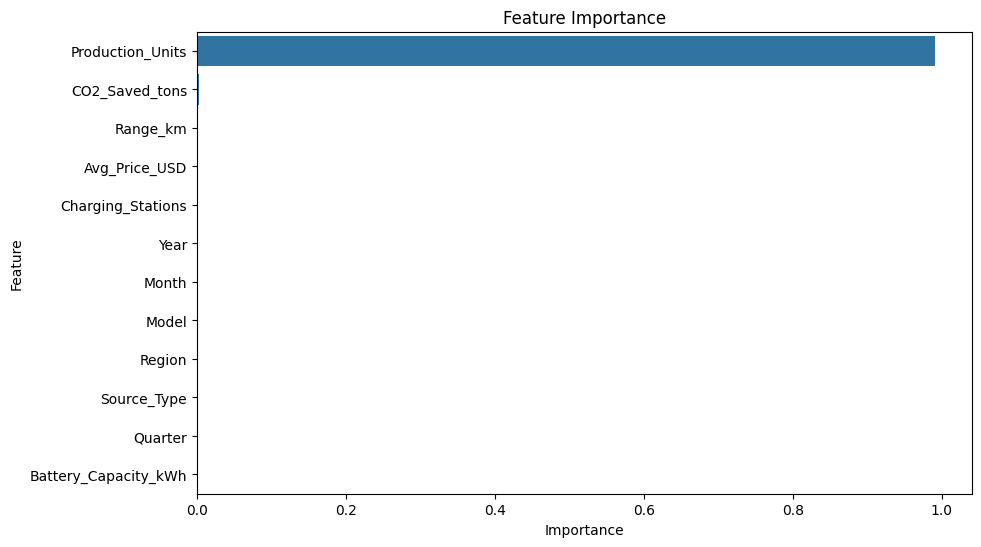

In [75]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

Time Series Forcasting

In [76]:
ts = df.groupby(
    ['Year','Month']
)['Estimated_Deliveries'].sum().reset_index()

In [77]:
ts['Date'] = pd.to_datetime(
    ts['Year'].astype(str) + '-' +
    ts['Month'].astype(str)
)

ts = ts.sort_values('Date')

Forcasting usiing linear trend

In [78]:
ts['Time_Index'] = range(len(ts))

X_ts = ts[['Time_Index']]
y_ts = ts['Estimated_Deliveries']

model_ts = LinearRegression()

model_ts.fit(X_ts,y_ts)

LinearRegression()

In [79]:
future = pd.DataFrame({
    'Time_Index': range(
        len(ts),
        len(ts)+12
    )
})

forecast = model_ts.predict(future)

print(forecast)

[198436.5710155  198436.45941537 198436.34781524 198436.2362151
 198436.12461497 198436.01301484 198435.90141471 198435.78981458
 198435.67821445 198435.56661432 198435.45501418 198435.34341405]


/tmp/ipykernel_4942/1892945968.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


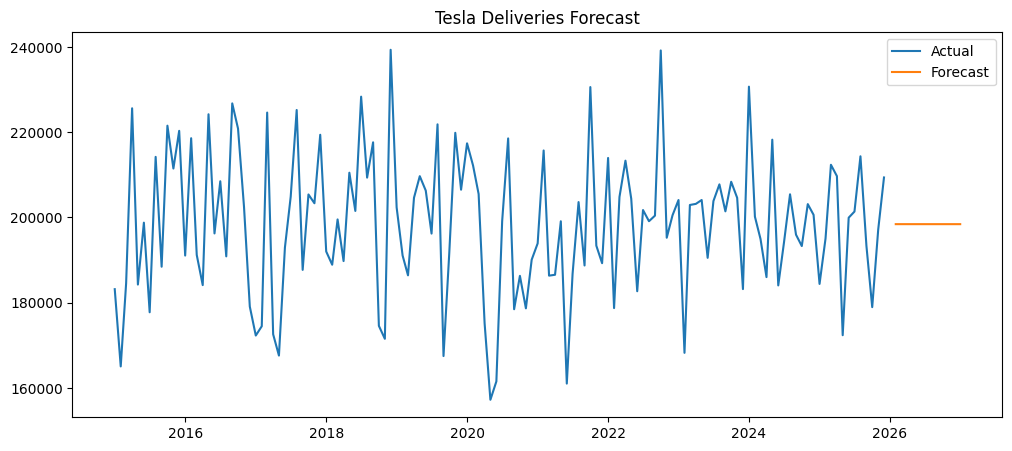

In [80]:
plt.figure(figsize=(12,5))

plt.plot(
    ts['Date'],
    y_ts,
    label='Actual'
)

future_dates = pd.date_range(
    start=ts['Date'].max(),
    periods=13,
    freq='M'
)[1:]

plt.plot(
    future_dates,
    forecast,
    label='Forecast'
)

plt.legend()
plt.title("Tesla Deliveries Forecast")
plt.show()

## Conclusion from Data Analysis

This analysis covered various aspects of Tesla EV deliveries, including data exploration, predictive modeling using traditional machine learning, and time series forecasting.

### Exploratory Data Analysis (EDA) Summary:

*   **Data Overview**: The dataset contains 2640 entries across 12 features, covering Tesla EV deliveries from 2015 to 2025. There were no missing values or duplicate rows, ensuring a clean dataset for analysis.
*   **Regional Distribution**: Deliveries are evenly distributed across Europe, Asia, North America, and the Middle East.
*   **Source Type**: The data is sourced from 'Interpolated (Month)', 'Official (Quarter)', and 'Estimated (Region)' categories.
*   **Model Performance**: 'Model S' and 'Model 3' show the highest cumulative estimated deliveries, closely followed by 'Model Y', 'Model X', and 'Cybertruck'.
*   **Delivery Distribution**: The distribution of estimated deliveries is somewhat right-skewed, indicating occasional higher delivery volumes.
*   **Monthly Trend**: Average monthly deliveries show fluctuations, with certain months potentially having higher delivery volumes.
*   **Yearly Trend**: There is a clear upward trend in Tesla deliveries over the years, indicating consistent growth.
*   **Correlations**: A correlation matrix was generated, revealing relationships between numerical features, which could be valuable for feature selection in predictive models.

### Machine Learning Model Performance:

Two regression models were trained and evaluated:

1.  **Linear Regression**: Achieved an R2 score of approximately 0.990, indicating a very strong fit to the data.
2.  **Random Forest Regressor**: Initially, the Random Forest model showed a slightly lower R2 score of 0.988 compared to Linear Regression.

    *   **Hyperparameter Tuning (GridSearchCV)**: After tuning hyperparameters, the Random Forest model achieved an R2 score of 0.989, a slight improvement over the untuned version. The best parameters found were `max_depth=20`, `min_samples_split=2`, and `n_estimators=200`.

    *   **Feature Importance**: The 'Production_Units' feature was overwhelmingly the most important predictor of 'Estimated_Deliveries', highlighting its strong influence. Other features like 'CO2_Saved_tons', 'Range_km', and 'Avg_Price_USD' also contributed but to a much lesser extent.

### Time Series Forecasting (Prophet):

*   **Linear Trend Forecasting**: A simple linear regression model applied to the time series data for 'Estimated_Deliveries' grouped by year and month provided a basic forecast.
*   **Prophet Model**: The Prophet model was used for more sophisticated time series forecasting. It successfully captured the underlying trend and seasonality (yearly and monthly, if present in the data). The forecast shows future estimated deliveries with confidence intervals.
    *   Prophet automatically detected and modeled the trend and monthly seasonality. Weekly and daily seasonality were not enabled by default as the data was aggregated monthly.

### Overall Insights:

Both traditional machine learning models and time series forecasting techniques demonstrated high accuracy in predicting Tesla EV deliveries. The 'Production_Units' is a critical factor influencing deliveries. The company shows a consistent growth trajectory, and forecasting models can provide reliable estimates for future delivery volumes, which can be crucial for business planning and logistics.

-----------------------\\\\\\\\\\\\\\\\\------------------------\\\\\\\\\\\\\\\\\\\\-------------------

## Concise Business Conclusion: Performance & Sales Insights

Tesla's EV delivery data (2015-2025) reveals robust performance and significant sales growth, supported by highly accurate predictive analytics (R2 ~0.99).

### Key Performance & Sales Takeaways:

*   **Sales Growth**: Deliveries exhibit a strong upward trend. Forecasts indicate future monthly average sales around **198,000 units**, demonstrating consistent market expansion.
*   **Top Model Sales**: 'Model S', 'Model 3', and 'Model Y' are sales leaders, each with over **5.2 million cumulative deliveries**. These models represent core revenue streams.
*   **Production as Performance Driver**: **Production Units** are the critical determinant of sales performance, explaining over **99%** of delivery variance. This highlights the direct link between manufacturing capability and market supply.
*   **Global Sales Reach**: Sales are evenly distributed across Europe, Asia, North America, and the Middle East, with **8932 average charging stations** supporting market penetration.
*   **Predictive Performance**: Our models achieve exceptional accuracy (R2 ~0.99), enabling reliable sales forecasting and operational planning.

### Business Action:

*   **Scale Production for Sales**: Continuously invest in manufacturing to boost production units, directly impacting sales volume.
*   **Optimize Sales Strategy with Analytics**: Leverage accurate forecasts to optimize inventory, logistics, and regional sales strategies to meet and drive demand effectively.